In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = sns.load_dataset("flights")

df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [4]:
df.isnull().sum()

,0
year,0
month,0
passengers,0


In [5]:
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str))

df.set_index("date", inplace=True)

ts = df["passengers"]

/tmp/ipykernel_240/2768704794.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str))


,year,month,passengers
date,,,
1949-01-01,1949,Jan,112
1949-02-01,1949,Feb,118
1949-03-01,1949,Mar,132
1949-04-01,1949,Apr,129
1949-05-01,1949,May,121
...,...,...,...
1960-08-01,1960,Aug,606
1960-09-01,1960,Sep,508
1960-10-01,1960,Oct,461


In [27]:
#simple moving avg

sma = ts.rolling(12).mean()

In [8]:
sma

,passengers
date,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
...,...
1960-08-01,463.333333
1960-09-01,467.083333
1960-10-01,471.583333


In [10]:
window = 12
sma = []

for i in range(len(ts)):
    if i < window-1:
        sma.append(None)
    else:
        avg = sum(ts[i-window+1:i+1]) / window
        sma.append(avg)

In [11]:
sma


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 126.66666666666667,
 126.91666666666667,
 127.58333333333333,
 128.33333333333334,
 128.83333333333334,
 129.16666666666666,
 130.33333333333334,
 132.16666666666666,
 134.0,
 135.83333333333334,
 137.0,
 137.83333333333334,
 139.66666666666666,
 142.16666666666666,
 144.16666666666666,
 147.25,
 149.58333333333334,
 153.5,
 155.91666666666666,
 158.33333333333334,
 160.75,
 162.91666666666666,
 165.33333333333334,
 168.0,
 170.16666666666666,
 172.33333333333334,
 174.83333333333334,
 176.08333333333334,
 177.58333333333334,
 178.5,
 181.83333333333334,
 184.41666666666666,
 188.0,
 190.08333333333334,
 192.5,
 194.66666666666666,
 197.0,
 199.08333333333334,
 200.41666666666666,
 204.0,
 208.5,
 212.33333333333334,
 214.41666666666666,
 217.25,
 219.75,
 222.08333333333334,
 223.75,
 224.41666666666666,
 225.0,
 225.66666666666666,
 225.0,
 224.91666666666666,
 224.25,
 224.66666666666666,
 226.416666666666

In [28]:
#cumulative moving avg
cma = ts.expanding().mean()


In [16]:
cma


,passengers
date,
1949-01-01,112.000000
1949-02-01,115.000000
1949-03-01,120.666667
1949-04-01,122.750000
1949-05-01,122.400000
...,...
1960-08-01,275.514286
1960-09-01,277.163121
1960-10-01,278.457746


In [12]:
cma = []
total = 0

for i in range(len(ts)):
    total += ts[i]
    avg = total / (i+1)
    cma.append(avg)

/tmp/ipykernel_240/936772605.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total += ts[i]


In [13]:
cma

[np.float64(112.0),
 np.float64(115.0),
 np.float64(120.66666666666667),
 np.float64(122.75),
 np.float64(122.4),
 np.float64(124.5),
 np.float64(127.85714285714286),
 np.float64(130.375),
 np.float64(131.0),
 np.float64(129.8),
 np.float64(127.45454545454545),
 np.float64(126.66666666666667),
 np.float64(125.76923076923077),
 np.float64(125.78571428571429),
 np.float64(126.8),
 np.float64(127.3125),
 np.float64(127.17647058823529),
 np.float64(128.38888888888889),
 np.float64(130.57894736842104),
 np.float64(132.55),
 np.float64(133.76190476190476),
 np.float64(133.72727272727272),
 np.float64(132.8695652173913),
 np.float64(133.16666666666666),
 np.float64(133.64),
 np.float64(134.26923076923077),
 np.float64(135.88888888888889),
 np.float64(136.85714285714286),
 np.float64(138.06896551724137),
 np.float64(139.4),
 np.float64(141.32258064516128),
 np.float64(143.125),
 np.float64(144.36363636363637),
 np.float64(144.88235294117646),
 np.float64(144.9142857142857),
 np.float64(145.5),

In [29]:
# exponential weighted moving avg
ewma = ts.ewm(span=12, adjust=False).mean()

In [23]:
ewma

,passengers
date,
1949-01-01,112.000000
1949-02-01,112.923077
1949-03-01,115.857988
1949-04-01,117.879836
1949-05-01,118.359861
...,...
1960-08-01,494.898619
1960-09-01,496.914216
1960-10-01,491.388952


In [24]:
span = 12
alpha = 2/(span+1)

ewma = []
prev = ts.iloc[0]

for value in ts:
    current = alpha * value + (1-alpha) * prev
    ewma.append(current)
    prev = current

In [25]:
ewma

[np.float64(112.0),
 np.float64(112.92307692307693),
 np.float64(115.85798816568048),
 np.float64(117.87983614019117),
 np.float64(118.35986134939253),
 np.float64(120.91988268025523),
 np.float64(125.08605457560058),
 np.float64(128.6112769485851),
 np.float64(129.7480035718797),
 np.float64(128.0944645608213),
 np.float64(124.38762385915649),
 np.float64(123.40491249620933),
 np.float64(122.11184903525405),
 np.float64(122.71002610675343),
 np.float64(125.52386824417599),
 np.float64(126.98173466814892),
 np.float64(126.67685241151062),
 np.float64(130.11118280973977),
 np.float64(136.24792391593365),
 np.float64(141.44055100579),
 np.float64(143.98815854336078),
 np.float64(142.29767261361297),
 np.float64(137.94418451921098),
 np.float64(138.26046382394776),
 np.float64(139.2973155433404),
 np.float64(140.9438823828265),
 np.float64(146.64482355469934),
 np.float64(149.16100454628406),
 np.float64(152.67469615454806),
 np.float64(156.57089674615605),
 np.float64(163.09845109290126)

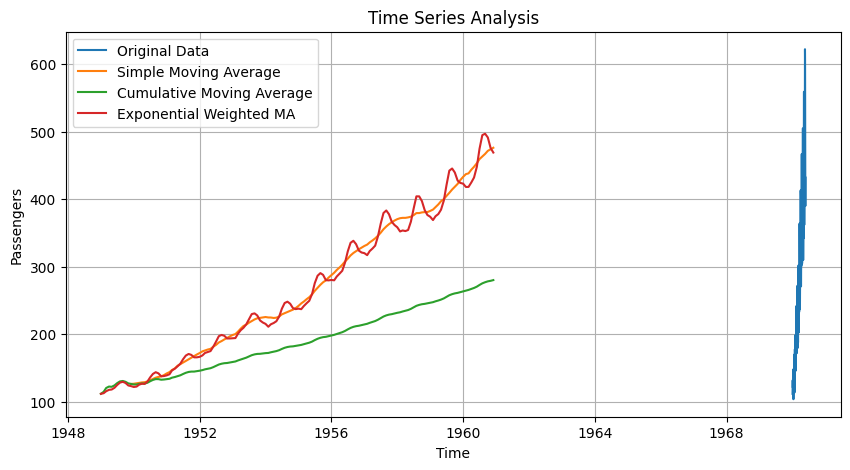

In [30]:
plt.figure(figsize=(10,5))

plt.plot(ts.values, label="Original Data")
plt.plot(sma, label="Simple Moving Average")
plt.plot(cma, label="Cumulative Moving Average")
plt.plot(ewma, label="Exponential Weighted MA")

plt.title("Time Series Analysis")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.legend()
plt.grid()

plt.show()